In [38]:
!pip install xgboost

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, mean_squared_error,
                             mean_absolute_error, r2_score)
from xgboost import XGBClassifier

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [40]:
plt.rcParams.update({
    'figure.facecolor': '#F7F9F2',
    'axes.facecolor':   '#F7F9F2',
    'axes.edgecolor':   '#AABF99',
    'axes.labelcolor':  '#2D4A1E',
    'xtick.color':      '#2D4A1E',
    'ytick.color':      '#2D4A1E',
    'text.color':       '#2D4A1E',
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

PALETTE = ['#4A7C2F','#8BC34A','#F4A261','#E76F51','#264653',
           '#2A9D8F','#E9C46A','#A8DADC','#C77DFF','#F4E285']

print("✅ Plot settings loaded!")

✅ Plot settings loaded!


In [41]:
from google.colab import files
uploaded = files.upload()

Saving Crop_recommendation.csv to Crop_recommendation (1).csv


In [42]:
df = pd.read_csv("Crop_recommendation.csv")

print("✅ Dataset Loaded Successfully!")
print(df.head())

✅ Dataset Loaded Successfully!
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [43]:
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df['label'].value_counts())


Dataset Shape:
(2200, 8)

Column Types:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Target Distribution:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [44]:
print(df.describe().round(2))

             N        P        K  temperature  humidity       ph  rainfall
count  2200.00  2200.00  2200.00      2200.00   2200.00  2200.00   2200.00
mean     50.55    53.36    48.15        25.62     71.48     6.47    103.46
std      36.92    32.99    50.65         5.06     22.26     0.77     54.96
min       0.00     5.00     5.00         8.83     14.26     3.50     20.21
25%      21.00    28.00    20.00        22.77     60.26     5.97     64.55
50%      37.00    51.00    32.00        25.60     80.47     6.43     94.87
75%      84.25    68.00    49.00        28.56     89.95     6.92    124.27
max     140.00   145.00   205.00        43.68     99.98     9.94    298.56


In [45]:
FEATURES = ['N', 'P', 'K', 'temperature',
            'humidity', 'ph', 'rainfall']

print(FEATURES)

['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


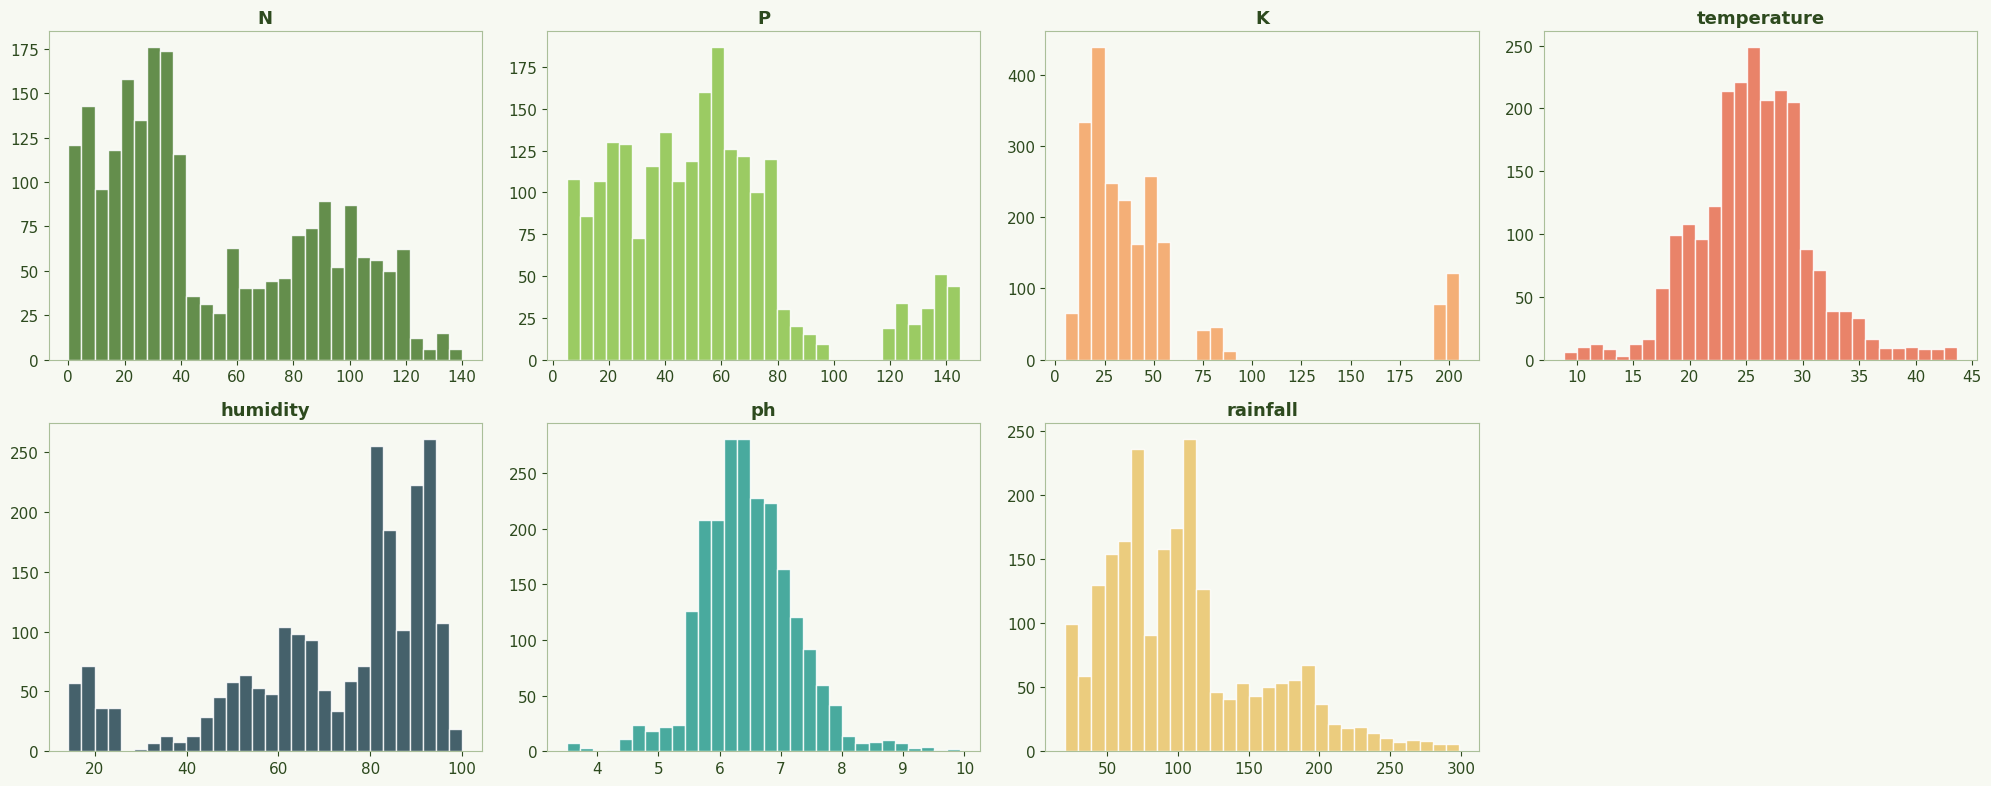

In [46]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    ax.hist(df[feat],
            bins=30,
            color=PALETTE[i % len(PALETTE)],
            edgecolor='white',
            alpha=0.85)

    ax.set_title(feat)

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

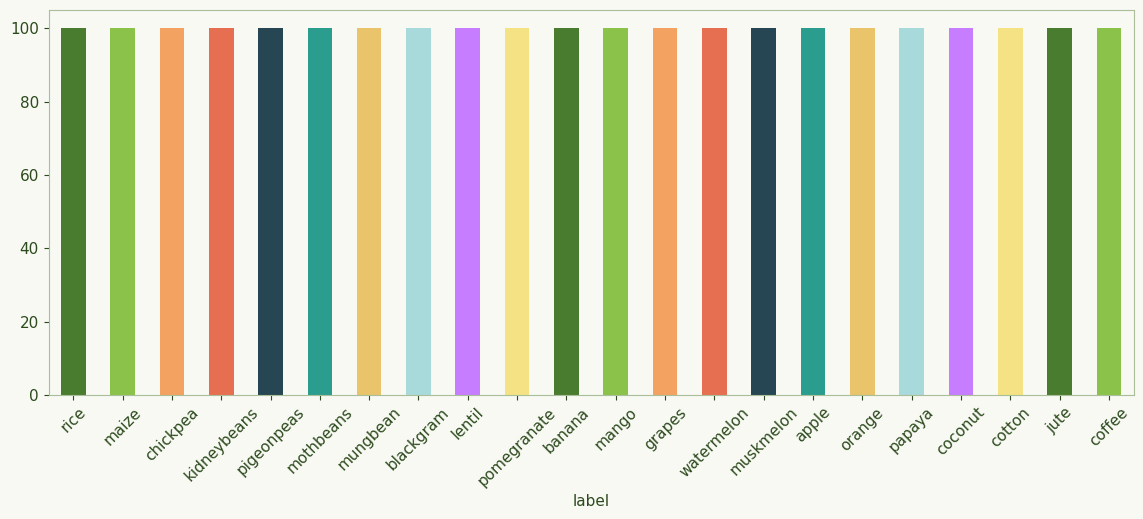

In [47]:
fig, ax = plt.subplots(figsize=(14,5))

order = df['label'].value_counts().index
colors = [PALETTE[i % len(PALETTE)] for i in range(len(order))]

df['label'].value_counts().plot(
    kind='bar',
    ax=ax,
    color=colors
)

plt.xticks(rotation=45)
plt.show()

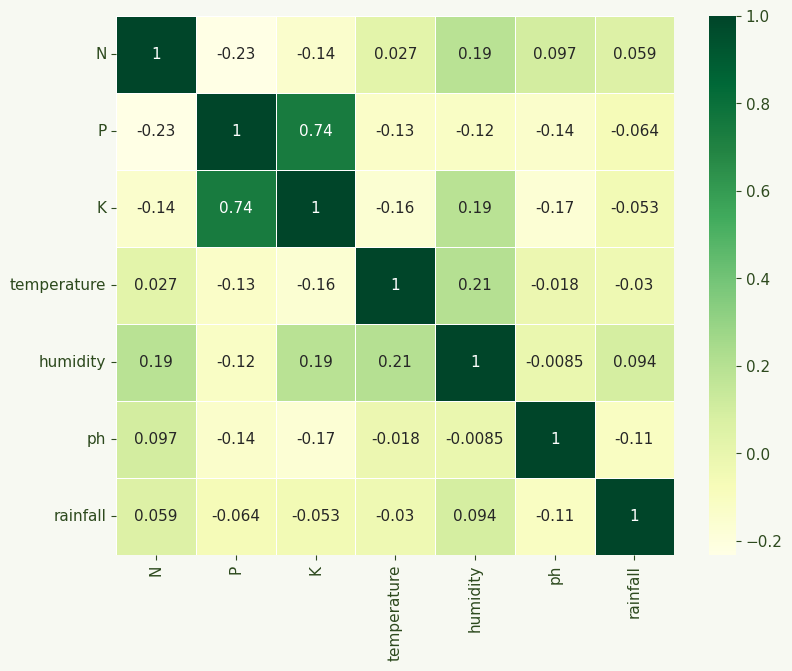

In [48]:
fig, ax = plt.subplots(figsize=(9,7))

corr = df[FEATURES].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="YlGn",
    linewidths=0.5
)

plt.show()

In [49]:
def engineer_features(data):

    d = data.copy()

    d['NPK_sum'] = d['N'] + d['P'] + d['K']

    d['NPK_ratio'] = d['N'] / (d['P'] + d['K'] + 1e-6)

    d['temp_humidity_idx'] = (
        d['temperature'] * d['humidity'] / 100
    )

    d['ph_deviation'] = abs(d['ph'] - 7.0)

    d['rain_efficiency'] = (
        d['rainfall'] / (d['humidity'] + 1e-6)
    )

    d['fertility_index'] = (
        0.4*d['N'] +
        0.35*d['P'] +
        0.25*d['K']
    )

    return d

In [50]:
df = engineer_features(df)

ENG_FEATURES = FEATURES + [
    'NPK_sum',
    'NPK_ratio',
    'temp_humidity_idx',
    'ph_deviation',
    'rain_efficiency',
    'fertility_index'
]

print(df.head())

    N   P   K  temperature   humidity        ph    rainfall label  NPK_sum  \
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice      175   
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice      184   
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice      159   
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice      149   
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice      162   

   NPK_ratio  temp_humidity_idx  ph_deviation  rain_efficiency  \
0   1.058824          17.121963      0.497015         2.474741   
1   0.858586          17.485957      0.038096         2.821919   
2   0.606061          18.937446      0.840207         3.206533   
3   0.986667          21.234829      0.019599         3.029803   
4   0.928571          16.427204      0.628473         3.219383   

   fertility_index  
0            61.45  
1            64.55  
2            54.25  
3            51.85  
4            56.40  


In [51]:
le = LabelEncoder()

df['crop_encoded'] = le.fit_transform(df['label'])

CROP_CLASSES = le.classes_

print(CROP_CLASSES)

['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


In [52]:
X = df[ENG_FEATURES].values

y_cls = df['crop_encoded'].values

In [53]:
np.random.seed(42)

base_yield = {
    c: np.random.uniform(1.5, 5.5)
    for c in CROP_CLASSES
}

df['yield_t_ha'] = (
    df['label'].map(base_yield)
    + 0.3 * (df['N']/100)
    + 0.2 * (df['rainfall']/200)
    - 0.1 * df['ph_deviation']
    + np.random.normal(0, 0.3, len(df))
)

df['yield_t_ha'] = df['yield_t_ha'].clip(0.5, 8.0)

y_reg = df['yield_t_ha'].values

In [54]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("✅ Scaling Completed")

✅ Scaling Completed


In [55]:
X_tr, X_te, yc_tr, yc_te = train_test_split(
    X_scaled,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

_, _, yr_tr, yr_te = train_test_split(
    X_scaled,
    y_reg,
    test_size=0.2,
    random_state=42
)

print(X_tr.shape)
print(X_te.shape)

(1760, 13)
(440, 13)


In [56]:
models = {

    "Decision Tree":
    DecisionTreeClassifier(
        max_depth=8,
        random_state=42
    ),

    "Gradient Boost":
    GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ),

    "XGBoost":
    XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
        verbosity=0
    )
}

In [ ]:
results = {}

for name, mdl in models.items():

    mdl.fit(X_tr, yc_tr)

    preds = mdl.predict(X_te)

    acc = accuracy_score(yc_te, preds)

    cv = cross_val_score(
        mdl,
        X_scaled,
        y_cls,
        cv=5,
        scoring='accuracy'
    ).mean()

    results[name] = {
        'model': mdl,
        'preds': preds,
        'acc': acc,
        'cv_acc': cv
    }

    print(name)
    print("Accuracy:", acc)
    print("CV Accuracy:", cv)
    print()

Decision Tree
Accuracy: 0.8636363636363636
CV Accuracy: 0.8840909090909091



In [ ]:
best_name = max(
    results,
    key=lambda k: results[k]['acc']
)

best_clf = results[best_name]['model']

print("Best Model:", best_name)

In [ ]:
print(classification_report(
    yc_te,
    results[best_name]['preds'],
    target_names=CROP_CLASSES
))

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))

names = list(results.keys())

accs = [results[n]['acc'] for n in names]

ax.bar(names, accs, color=PALETTE[:3])

plt.ylim(0,1)

plt.show()

In [ ]:
cm = confusion_matrix(
    yc_te,
    results[best_name]['preds']
)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGn'
)

plt.show()

In [ ]:
xgb_mdl = results['XGBoost']['model']

importances = xgb_mdl.feature_importances_

feat_df = pd.DataFrame({
    'Feature': ENG_FEATURES,
    'Importance': importances
})

feat_df = feat_df.sort_values(
    'Importance',
    ascending=True
)

plt.figure(figsize=(9,7))

plt.barh(
    feat_df['Feature'],
    feat_df['Importance']
)

plt.show()

In [ ]:
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_tr, yr_tr)

yr_pred = rf_reg.predict(X_te)

In [ ]:
rmse = np.sqrt(
    mean_squared_error(yr_te, yr_pred)
)

mae = mean_absolute_error(
    yr_te,
    yr_pred
)

r2 = r2_score(
    yr_te,
    yr_pred
)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    yr_te,
    yr_pred,
    alpha=0.5
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.show()

In [ ]:
def get_crop_recommendation(
    N, P, K,
    temperature,
    humidity,
    ph,
    rainfall
):

    row = pd.DataFrame([{
        'N': N,
        'P': P,
        'K': K,
        'temperature': temperature,
        'humidity': humidity,
        'ph': ph,
        'rainfall': rainfall
    }])

    row = engineer_features(row)

    X_input = scaler.transform(
        row[ENG_FEATURES].values
    )

    probs = best_clf.predict_proba(X_input)[0]

    top_idx = np.argmax(probs)

    crop = CROP_CLASSES[top_idx]

    confidence = probs[top_idx] * 100

    yield_pred = rf_reg.predict(X_input)[0]

    print("Recommended Crop:", crop)
    print("Confidence:", round(confidence,2), "%")
    print("Expected Yield:", round(yield_pred,2))

In [ ]:
get_crop_recommendation(
    N=90,
    P=42,
    K=43,
    temperature=20.9,
    humidity=82.0,
    ph=6.5,
    rainfall=202.9
)

In [ ]:
print("✅ PROJECT COMPLETED")

print("Best Model:", best_name)

print("Accuracy:",
      results[best_name]['acc'])

print("RMSE:", rmse)

print("R2:", r2)